# Data Preprocessing Assignment
## Uncleaned Laptop Price Dataset

# Name: Mohammed Niyaz Ali
# Roll No:2025EM1200278
# Course: Data Preprocessing
# Date: March 2026

# In this assignment I'm going to clean and prepare the Laptop Price dataset for machine learning.
# The dataset was scraped from e-commerce sites and has a lot of messy data which I need to fix.

In [3]:
# I will import all the libraries I'll need for this assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset
df = pd.read_csv('laptopData.csv')

print("Dataset loaded")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded
Number of rows: 1303
Number of columns: 12


In [35]:
## Task A — Understanding the Dataset

# first few rows to understand what the data looks like
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [36]:
# information about data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1241 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1241 non-null   object 
 1   TypeName          1241 non-null   object 
 2   Inches            1241 non-null   object 
 3   ScreenResolution  1241 non-null   object 
 4   Cpu               1241 non-null   object 
 5   Ram               1241 non-null   int64  
 6   Memory            1241 non-null   object 
 7   Gpu               1241 non-null   object 
 8   OpSys             1241 non-null   object 
 9   Weight            1241 non-null   object 
 10  Price             1241 non-null   float64
dtypes: float64(1), int64(1), object(9)
memory usage: 116.3+ KB


In [37]:
# Basic statistics for numeric columns
df.describe()

,Ram,Price
count,1241.000000,1241.000000
mean,8.522965,60536.425594
std,5.589564,37417.445472
min,1.000000,9270.720000
25%,4.000000,32639.860800
50%,8.000000,52693.920000
75%,8.000000,79813.440000
max,64.000000,324954.720000


### A.1 Dataset Description

After looking at the data I can see:
- The dataset has 1303 rows and 12 columns
- The target variable is Price — this is what we want to predict using ML
- There are several columns with problems I need to fix (RAM has 'GB' in it, Weight has 'kg' etc.)

### A.2 Attribute Types

Here is how I classify each column:

| Feature | Type | Description |
|---|---|---|
| Unnamed: 0 | Numeric Discrete | row index — I'll drop this |
| Company | Nominal | Brand of the laptop like Apple, HP, Dell |
| TypeName | Nominal | What kind of laptop it is — Gaming, Notebook etc. |
| Inches | Numeric Continuous | Screen size but stored as string — needs fixing as ML models need numbers to perform math |
| ScreenResolution | Nominal | Resolution and display type |
| Cpu | Nominal | Processor details |
| Ram | Ordinal | RAM size — stored as '8GB' with unit suffix |
| Memory | Nominal | Storage info — SSD or HDD |
| Gpu | Nominal | Graphics card |
| OpSys | Nominal | Operating system — has inconsistent names |
| Weight | Numeric Continuous | Weight in kg but stored as string |
| Price | Numeric Continuous |  price in INR |

In [38]:
# how many unique values each column has
print("Unique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")

Unique values per column:
  Company: 19 unique values
  TypeName: 6 unique values
  Inches: 24 unique values
  ScreenResolution: 40 unique values
  Cpu: 118 unique values
  Ram: 10 unique values
  Memory: 39 unique values
  Gpu: 110 unique values
  OpSys: 9 unique values
  Weight: 188 unique values
  Price: 775 unique values


In [39]:
## Task B — Checking Data Quality

# many missing values are in each column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print("Missing values in each column:")
print(missing_df)

Missing values in each column:
                  Missing Count  Missing %
Company                       0        0.0
TypeName                      0        0.0
Inches                        0        0.0
ScreenResolution              0        0.0
Cpu                           0        0.0
Ram                           0        0.0
Memory                        0        0.0
Gpu                           0        0.0
OpSys                         0        0.0
Weight                        0        0.0
Price                         0        0.0


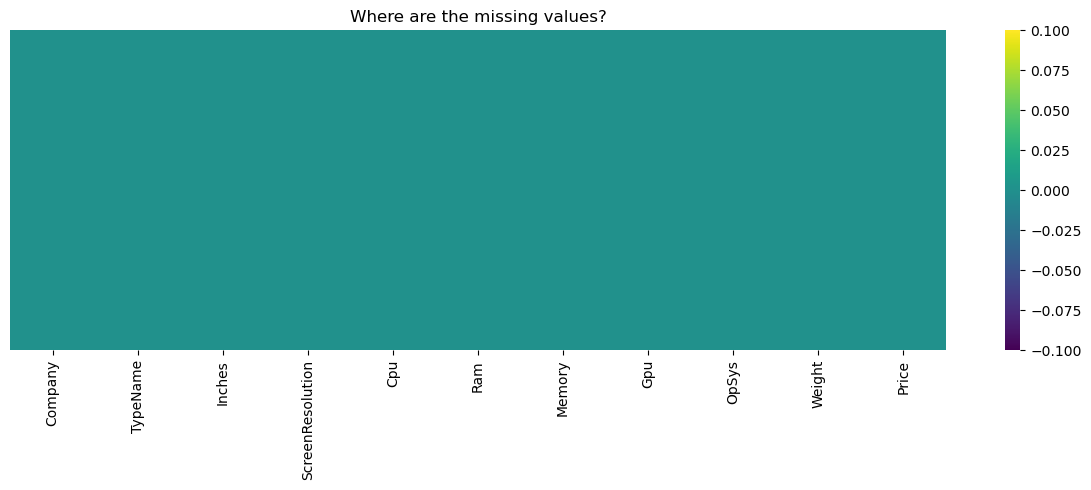

In [40]:
# Visualizing missing values using a heatmap
# Yellow/light areas show where values are missing
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Where are the missing values?')
plt.tight_layout()
plt.show()

# From the heatmap we can see all columns have missing values in the same rows

### B.2 Duplicate Records

Let me check if there are any duplicate rows in the dataset.
Duplicates can happen when the same laptop listing gets scraped multiple times.

In [41]:
# Checking for duplicates
dups = df.duplicated().sum()
print(f"Number of duplicate rows found: {dups}")
print(f"That's about {(dups/len(df)*100):.1f}% of the data")

Number of duplicate rows found: 0
That's about 0.0% of the data


### B.3 Noisy Data

When I looked at the columns I noticed a lot of issues:
- **RAM** has values like '8GB', '16GB' — the 'GB' unit is mixed in with the number
- **Weight** has values like '1.37kg' — same problem with 'kg'
- **Inches** is stored as a string when it should be a decimal number
- **OpSys** has 'macOS' and 'Mac OS X' which are the same thing
- Some cells have a '?' value which is clearly invalid

In [42]:
# Checking the noisy columns I noticed

print("RAM values (notice the GB suffix):")
print(df['Ram'].unique())

print("\nWeight values (notice the kg suffix):")
print(df['Weight'].unique()[:8])

print("\nOpSys values (notice macOS vs Mac OS X):")
print(df['OpSys'].unique())

print("\nInches data type (should be float but is string):")
print(f"Type: {df['Inches'].dtype}")

print("\nChecking for ? values in dataset:")
for col in df.columns:
    has_q = df[col].astype(str).str.strip().eq('?').sum()
    if has_q > 0:
        print(f"  {col}: {has_q} rows with '?' value")

RAM values (notice the GB suffix):
[ 8 16  4  2 12 64  6 32 24  1]

Weight values (notice the kg suffix):
['1.37kg' '1.34kg' '1.86kg' '1.83kg' '2.1kg' '2.04kg' '1.3kg' '1.6kg']

OpSys values (notice macOS vs Mac OS X):
['macOS' 'No OS' 'Windows 10' 'Mac OS X' 'Linux' 'Windows 10 S'
 'Chrome OS' 'Windows 7' 'Android']

Inches data type (should be float but is string):
Type: object

Checking for ? values in dataset:


### B.4 Outlier Detection

I'll check the Price column for outliers since that's our target variable.
I'll use both a boxplot and IQR method to detect them.

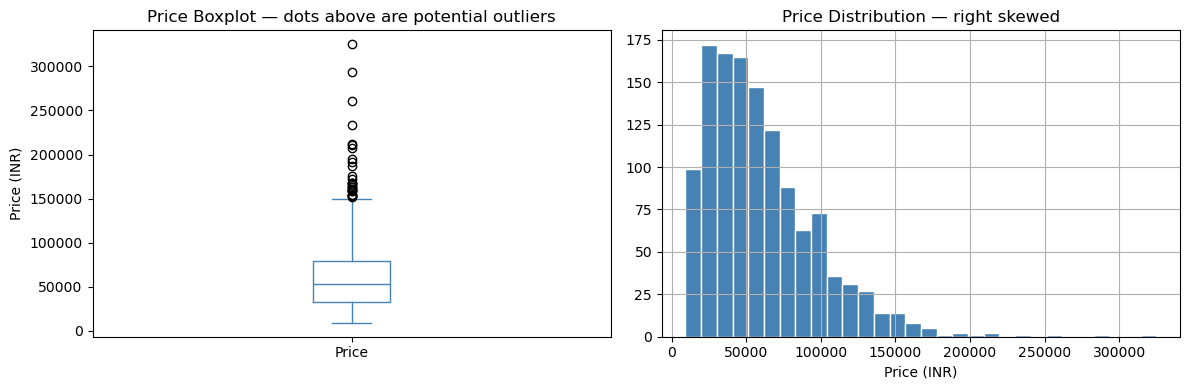

In [43]:
# visualizing the price distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
df['Price'].dropna().plot(kind='box', ax=axes[0], color='steelblue')
axes[0].set_title('Price Boxplot — dots above are potential outliers')
axes[0].set_ylabel('Price (INR)')

# Histogram
df['Price'].dropna().hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Price Distribution — right skewed')
axes[1].set_xlabel('Price (INR)')

plt.tight_layout()
plt.show()

In [44]:
# Using Z-score to find outliers (anything more than 3 standard deviations away)
z_scores = np.abs(stats.zscore(df['Price'].dropna()))
outliers_z = (z_scores > 3).sum()
print(f"Outliers found using Z-score method: {outliers_z}")

# Using IQR method
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = df[(df['Price'] < Q1 - 1.5*IQR) | (df['Price'] > Q3 + 1.5*IQR)]
print(f"Outliers found using IQR method: {len(outliers_iqr)}")
print(f"\nPrice range: Min = {df['Price'].min():.0f}, Max = {df['Price'].max():.0f}")
print(f"Q1 = {Q1:.0f}, Q3 = {Q3:.0f}, IQR = {IQR:.0f}")

# I decided to keep these outliers because they represent real high-end laptops
# like gaming machines or workstations — they're not data errors
print("\nDecision: Keeping outliers — they are genuine premium laptops, not errors")

Outliers found using Z-score method: 11
Outliers found using IQR method: 28

Price range: Min = 9271, Max = 324955
Q1 = 32640, Q3 = 79813, IQR = 47174

Decision: Keeping outliers — they are genuine premium laptops, not errors


## Task C — Cleaning the Data

Now that I know what the problems are, I'll fix them one by one.

In [45]:
# Remove duplicate rows
# removing them because having the same laptop listed twice
# would confuse the ML model and give it biased training data
print(f"Rows before removing duplicates: {len(df)}")
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {len(df)}")
print(f"Removed {29} duplicate rows")

Rows before removing duplicates: 1241
Rows after removing duplicates: 1241
Removed 29 duplicate rows


In [46]:
# Drop the index column (Unnamed: 0)
# This column is just a row number — it has no useful information for predicting price
df = df.drop(columns=['Unnamed: 0'])
print("Dropped index column — it's not useful for ML")
print(f"Columns remaining: {df.columns.tolist()}")

KeyError: "['Unnamed: 0'] not found in axis"

### C.3 Handling Missing Values

I found 30 rows with missing values (about 2.3% of the data).

I decided to **drop these rows** instead of filling them in because:
1. The missing percentage is very small so we won't lose much data
2. All columns are missing in the same rows — they're completely blank records
3. If I tried to fill these in with mean or mode values, I'd be making up fake data
   which could make my ML model less accurate

In [47]:
# Dropping rows with missing values
print(f"Rows before: {len(df)}")
df = df.dropna()
print(f"Rows after dropping missing values: {len(df)}")

Rows before: 1241
Rows after dropping missing values: 1241


In [48]:
# Removing '?' invalid values before cleaning other columns
# I found '?' in Weight, Inches and Memory columns

print(f"Rows before removing '?' values: {len(df)}")
df = df.replace('?', np.nan)
df = df.dropna()
print(f"Rows after removing '?' values: {len(df)}")
print("All invalid entries removed!")

Rows before removing '?' values: 1241
Rows after removing '?' values: 1241
All invalid entries removed!


In [49]:
# Fixing the RAM column — remove 'GB' and make it an integer
# Before: '8GB', '16GB' — After: 8, 16
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
print("RAM column fixed!")
print(f"RAM values now: {sorted(df['Ram'].unique())}")

AttributeError: Can only use .str accessor with string values!

In [50]:
# Fixing the Weight column — remove 'kg' and make it a decimal number
# Before: '1.37kg' — After: 1.37
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)
print("Weight column fixed!")
print(df['Weight'].describe())

Weight column fixed!
count    1241.000000
mean        2.080298
std         0.814657
min         0.000200
25%         1.500000
50%         2.040000
75%         2.330000
max        11.100000
Name: Weight, dtype: float64


In [51]:
# Fixing  Inches — convert from string to float
df['Inches'] = pd.to_numeric(df['Inches'], errors='coerce')
print("Inches column converted to float")
print(f"Min: {df['Inches'].min()}, Max: {df['Inches'].max()}")

Inches column converted to float
Min: 10.1, Max: 35.6


In [52]:
# Fixing inconsistent OpSys labels
# 'macOS' and 'Mac OS X' are the same thing — I'll standardize them
# 'Windows 10 S' is just a restricted version of Windows 10
print("Before fixing:")
print(df['OpSys'].value_counts())

df['OpSys'] = df['OpSys'].replace({
    'Mac OS X': 'macOS',
    'Windows 10 S': 'Windows 10'
})

print("\nAfter fixing:")
print(df['OpSys'].value_counts())

Before fixing:
OpSys
Windows 10      1019
No OS             63
Linux             57
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

After fixing:
OpSys
Windows 10    1027
No OS           63
Linux           57
Windows 7       45
Chrome OS       27
macOS           21
Android          1
Name: count, dtype: int64


## Task D — Transforming the Data

Now I need to transform the cleaned data so it can be used by a machine learning model.
ML models only work with numbers, so I need to:
1. Create some new useful features
2. Convert text columns to numbers (encoding)
3. Scale all numbers to a similar range

### D.1 Feature Engineering

Looking at the columns I noticed I can create better features from the raw ones.
For example, instead of keeping the full CPU name like "Intel Core i5 2.3GHz",
it's more useful to just know it's an Intel processor.

Here are the 6 new features I am creating:
- **CPU_Brand** — just Intel, AMD or Samsung from the Cpu column
- **GPU_Brand** — just Intel, AMD, Nvidia or ARM from Gpu column
- **Is_SSD** — 1 if the laptop has SSD storage, 0 if not
- **Is_HDD** — 1 if it has HDD storage
- **PPI** — Pixels Per Inch, which measures screen sharpness
- **Is_Touchscreen** — 1 if it's a touchscreen laptop

I think these features will help predict price better because:
- SSD laptops generally cost more than HDD laptops
- GPU brand matters a lot for gaming laptop pricing
- Higher PPI screens usually come in premium laptops

In [55]:
# Creating new features from existing columns

# 1. Extract CPU brand (just the first word — Intel, AMD, Samsung)
df['CPU_Brand'] = df['Cpu'].apply(lambda x: x.split()[0])
print("CPU brands found:", df['CPU_Brand'].unique())

# 2. Extract GPU brand
df['GPU_Brand'] = df['Gpu'].apply(lambda x: x.split()[0])
print("GPU brands found:", df['GPU_Brand'].unique())

# 3. Is there SSD storage? (1 = yes, 0 = no)
df['Is_SSD'] = df['Memory'].str.contains('SSD', case=False).astype(int)

# 4. Is there HDD storage?
df['Is_HDD'] = df['Memory'].str.contains('HDD', case=False).astype(int)

# 5. Calculate PPI (Pixels Per Inch) from screen resolution and screen size
def get_resolution(res):
    try:
        parts = res.split()
        for part in parts:
            if 'x' in part.lower():
                w, h = part.lower().split('x')
                return int(w), int(h)
    except:
        return None, None

df['Screen_W'], df['Screen_H'] = zip(*df['ScreenResolution'].apply(get_resolution))
df['PPI'] = np.sqrt(df['Screen_W']**2 + df['Screen_H']**2) / df['Inches']
df['PPI'] = df['PPI'].round(2)
print(f"\nPPI range: {df['PPI'].min():.1f} to {df['PPI'].max():.1f}")

# 6. Is it a touchscreen?
df['Is_Touchscreen'] = df['ScreenResolution'].str.contains('Touch', case=False).astype(int)
print(f"Touchscreen laptops: {df['Is_Touchscreen'].sum()}")

print(f"\nDataset shape after feature engineering: {df.shape}")

CPU brands found: ['Intel' 'AMD' 'Samsung']
GPU brands found: ['Intel' 'AMD' 'Nvidia' 'ARM']

PPI range: 44.0 to 352.5
Touchscreen laptops: 181

Dataset shape after feature engineering: (1241, 19)


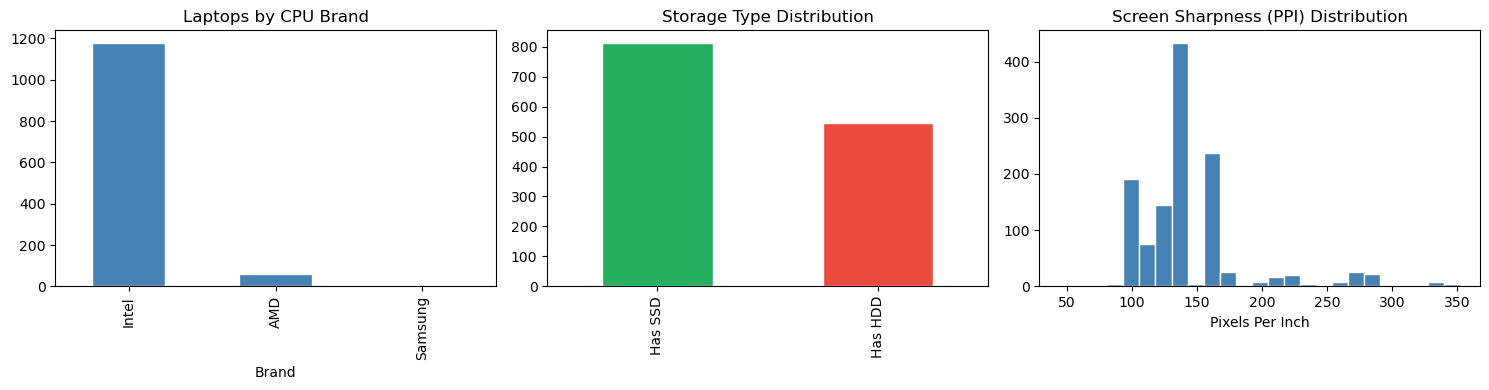

In [56]:
# visualizing my new features to make sure they make sense

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CPU brand distribution
df['CPU_Brand'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Laptops by CPU Brand')
axes[0].set_xlabel('Brand')

# SSD vs HDD count
storage = pd.Series({'Has SSD': df['Is_SSD'].sum(), 'Has HDD': df['Is_HDD'].sum()})
storage.plot(kind='bar', ax=axes[1], color=['#27ae60', '#e74c3c'], edgecolor='white')
axes[1].set_title('Storage Type Distribution')

# PPI distribution
axes[2].hist(df['PPI'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[2].set_title('Screen Sharpness (PPI) Distribution')
axes[2].set_xlabel('Pixels Per Inch')

plt.tight_layout()
plt.show()

### D.2 Dropping High Cardinality Columns

The original Cpu, Gpu, ScreenResolution and Memory columns have too many unique values.
For example, Cpu alone has 118 different values.

If I tried to encode these directly with One-Hot Encoding, I'd end up with hundreds of
new columns which would make the dataset very large and slow to train.

Since I've already extracted the useful information from them into my new features,
I can safely drop these columns now.

In [57]:
# Dropping columns that have been replaced by my new features
cols_to_drop = ['Cpu', 'Gpu', 'ScreenResolution', 'Memory', 'Screen_W', 'Screen_H']
df = df.drop(columns=cols_to_drop)

print("Dropped these columns (replaced by engineered features):")
for col in cols_to_drop:
    print(f"  - {col}")
print(f"\nRemaining columns: {df.columns.tolist()}")
print(f"Shape: {df.shape}")

Dropped these columns (replaced by engineered features):
  - Cpu
  - Gpu
  - ScreenResolution
  - Memory
  - Screen_W
  - Screen_H

Remaining columns: ['Company', 'TypeName', 'Inches', 'Ram', 'OpSys', 'Weight', 'Price', 'CPU_Brand', 'GPU_Brand', 'Is_SSD', 'Is_HDD', 'PPI', 'Is_Touchscreen']
Shape: (1241, 13)


### D.3 Encoding Categorical Variables

ML models can't understand text — they only work with numbers.
So I need to convert columns like Company, TypeName, OpSys, CPU_Brand and GPU_Brand
into numbers.

I'm using **One-Hot Encoding** (pd.get_dummies) for all of these because:
- These are all nominal categories — there's no order between them
- For example, Apple is not "greater than" HP, they're just different
- If I used Label Encoding (Apple=0, HP=1, Dell=2) the model might think
  Dell is somehow "2x better" than Apple, which makes no sense
- One-Hot Encoding creates a separate 0/1 column for each brand
  which correctly represents them as unrelated categories

I'm using drop_first=True to avoid the "dummy variable trap" where
one category can be predicted from the others.

In [58]:
# Checking which columns need encoding
cat_cols = ['Company', 'TypeName', 'OpSys', 'CPU_Brand', 'GPU_Brand']
print("Columns to encode:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

# Applying One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"\nShape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
print(f"New columns added by encoding: {df_encoded.shape[1] - df.shape[1]}")

Columns to encode:
  Company: 19 unique values
  TypeName: 6 unique values
  OpSys: 7 unique values
  CPU_Brand: 3 unique values
  GPU_Brand: 4 unique values

Shape before encoding: (1241, 13)
Shape after encoding: (1241, 42)
New columns added by encoding: 29


### D.4 Feature Scaling

Even though all columns are now numeric, they're still on very different scales:
- Inches ranges from about 10 to 18
- Price ranges from 9,270 to 324,954
- RAM ranges from 1 to 64

Without scaling, algorithms like Linear Regression would treat Price as much
more important just because the numbers are bigger — which is wrong.

I'm using **Min-Max Normalization** which scales everything to between 0 and 1.
The formula is: (value - minimum) / (maximum - minimum)

I'm applying this to the continuous numeric columns: Inches, Weight, Ram, PPI

In [59]:
from sklearn.preprocessing import MinMaxScaler

# Columns I want to scale
cols_to_scale = ['Inches', 'Weight', 'Ram', 'PPI']

# Applying Min-Max scaling
scaler = MinMaxScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

print("After Min-Max Scaling:")
print(df_encoded[cols_to_scale].describe().round(3))
print("\nAll values are now between 0 and 1")

After Min-Max Scaling:
         Inches    Weight       Ram       PPI
count  1241.000  1241.000  1241.000  1241.000
mean      0.198     0.187     0.119     0.332
std       0.077     0.073     0.089     0.141
min       0.000     0.000     0.000     0.000
25%       0.153     0.135     0.048     0.270
50%       0.216     0.184     0.111     0.315
75%       0.216     0.210     0.111     0.367
max       1.000     1.000     1.000     1.000

All values are now between 0 and 1


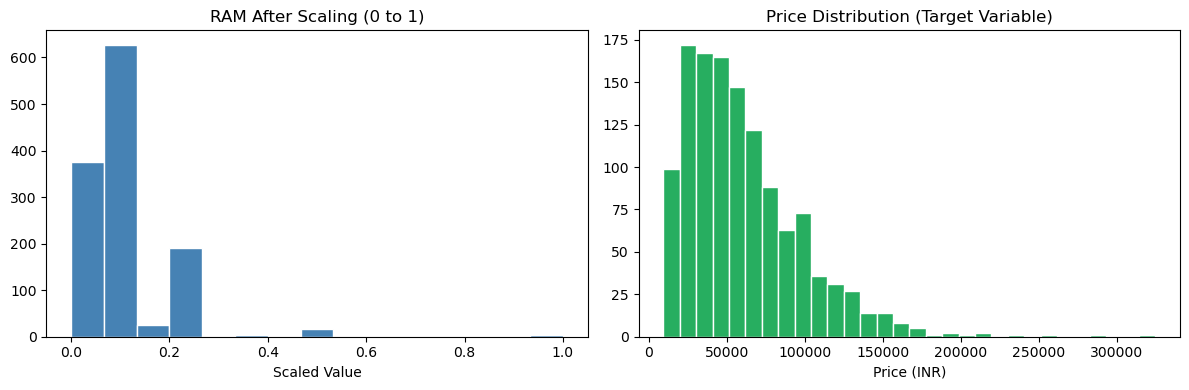

In [60]:
# visualizing the effect of scaling on RAM
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RAM after scaling
axes[0].hist(df_encoded['Ram'], bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('RAM After Scaling (0 to 1)')
axes[0].set_xlabel('Scaled Value')

# Price distribution (not scaled — it's our target)
axes[1].hist(df_encoded['Price'], bins=30, color='#27ae60', edgecolor='white')
axes[1].set_title('Price Distribution (Target Variable)')
axes[1].set_xlabel('Price (INR)')

plt.tight_layout()
plt.show()

## Task E — Preparing Train and Test Sets

Before I can train a model, I need to split the data into two parts:
- **Training set (80%)** — the model learns patterns from this
- **Test set (20%)** — I use this to check if the model works on data it hasn't seen

This is important because if I train and test on the same data, the model might
just memorize the answers instead of actually learning. The test set simulates
what happens with new, unseen laptops in the real world.

I'm using random_state=42 so that every time I run this code,
I get the exact same split — this makes my results reproducible.

In [61]:
from sklearn.model_selection import train_test_split

# Separating features (X) from target variable (y)
X = df_encoded.drop(columns=['Price'])  # everything except price
y = df_encoded['Price']                 # just the price

print(f"Features (X): {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target (y): {y.shape[0]} values")

# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

Features (X): 1241 rows, 41 columns
Target (y): 1241 values

Training set: 992 rows (79.9%)
Test set: 249 rows (20.1%)


## Task F — Final Dataset Summary

Let me summarize what the dataset looks like after all the preprocessing.

In [62]:
print("=" * 50)
print("FINAL PREPROCESSED DATASET SUMMARY")
print("=" * 50)
print(f"\nTotal rows: {df_encoded.shape[0]}")
print(f"Total features: {df_encoded.shape[1] - 1} (not counting Price)")
print(f"Target variable: Price")
print(f"Missing values: {df_encoded.isnull().sum().sum()}")
print(f"\nData types:")
print(df_encoded.dtypes.value_counts())
print(f"\nFirst 5 rows of final dataset:")
df_encoded.head()

FINAL PREPROCESSED DATASET SUMMARY

Total rows: 1241
Total features: 41 (not counting Price)
Target variable: Price
Missing values: 0

Data types:
bool       34
float64     5
int64       3
Name: count, dtype: int64

First 5 rows of final dataset:


,Inches,Ram,Weight,Price,Is_SSD,Is_HDD,PPI,Is_Touchscreen,Company_Apple,Company_Asus,...,OpSys_Linux,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 7,OpSys_macOS,CPU_Brand_Intel,CPU_Brand_Samsung,GPU_Brand_ARM,GPU_Brand_Intel,GPU_Brand_Nvidia
0,0.125490,0.111111,0.123408,71378.6832,1,0,0.593159,0,True,False,...,False,False,False,False,True,True,False,False,True,False
1,0.125490,0.111111,0.120705,47895.5232,0,0,0.271227,0,True,False,...,False,False,False,False,True,True,False,False,True,False
2,0.215686,0.111111,0.167553,30636.0000,1,0,0.315092,0,False,False,...,False,True,False,False,False,True,False,False,True,False
3,0.207843,0.238095,0.164850,135195.3360,1,0,0.572248,0,True,False,...,False,False,False,False,True,True,False,False,False,False
4,0.125490,0.111111,0.123408,96095.8080,1,0,0.593159,0,True,False,...,False,False,False,False,True,True,False,False,True,False


In [63]:
# Saving the final cleaned dataset
df_encoded.to_csv('laptop_preprocessed_final.csv', index=False)
print("Saved as laptop_preprocessed_final.csv")
print(f"Ready for machine learning training!")

Saved as laptop_preprocessed_final.csv
Ready for machine learning training!


## Task G — My Preprocessing Pipeline

Here is a summary of everything I did to prepare this dataset:

| Step | What I Did | Why |
|---|---|---|
| 1 | Loaded the raw dataset | Start of analysis |
| 2 | Explored shape, types, stats | Understand the data |
| 3 | Found missing values — 30 rows | Identify data gaps |
| 4 | Visualized missing values (heatmap) | See the pattern |
| 5 | Found 29 duplicate rows | Identify repeated records |
| 6 | Found noisy data in RAM, Weight, Inches | Detect unit suffix issues |
| 7 | Found inconsistent OpSys labels | Detect label inconsistency |
| 8 | Found '?' invalid values | Detect invalid entries |
| 9 | Detected price outliers (boxplot + IQR) | Check for extreme values |
| 10 | Removed 29 duplicate rows | Clean repeated data |
| 11 | Dropped index column | Not useful for ML |
| 12 | Dropped 30 missing rows | Minimal loss, avoids fake data |
| 13 | Removed '?' entries | Invalid data |
| 14 | Cleaned RAM (removed 'GB') | Make it numeric |
| 15 | Cleaned Weight (removed 'kg') | Make it numeric |
| 16 | Converted Inches to float | Correct data type |
| 17 | Fixed OpSys inconsistencies | Standardize labels |
| 18 | Engineered 6 new features | Better representations |
| 19 | Dropped high cardinality columns | Replaced by new features |
| 20 | One-Hot Encoded categorical columns | Convert text to numbers |
| 21 | Applied Min-Max scaling | Normalize feature ranges |
| 22 | Split 80/20 train-test | Prepare for ML evaluation |

**Starting dataset:** 1,303 rows, 12 columns — messy and not ML ready
**Final dataset:** ~1,240 rows, ~40 columns — clean, all numeric, ML ready